---
title: "Decision-theoretic drill planning"
subtitle: "A POMDP framing for sequential exploration on the BCGT prior"
author: "Sky King"
date: "2026-05"
format:
  html:
    toc: true
    toc-depth: 3
    code-fold: true
    number-sections: true
execute:
  warning: false
---

## Why decision-theoretic drill planning matters

A prospectivity model gives you a per-cell probability that a deposit
exists. It does *not* tell you where to drill *next* given what you've
already drilled. Real exploration campaigns are sequential: each hole
costs roughly $0.5–2M, returns information about the local geology,
and that information should change the next-hole decision.

[ExploreTech][et] and [KoBold's Stanford Mineral-X collaboration][kobold]
build their decision layer on exactly this observation: drill planning
is a **partially observable Markov decision process** (POMDP), and a
Monte-Carlo-tree-search planner can substantially outperform fixed-grid
or greedy-prior campaigns at the per-dollar-spent margin. The
methodological reference is *Intelligent Prospector* v1.0
([Mern et al., GMD 2023][mern1]) and v2.0 ([arXiv 2410.10610, 2024][mern2]).

This notebook ports that framework — at the v1.0 (single-hypothesis)
fidelity — onto the [BCGT prospectivity prior][bcgt-rf] and runs three
policies side by side: random, greedy, and POMCP. It is a methodology
demonstration, not a state-of-the-art benchmark — see
*[What this doesn't establish](#what-this-doesnt-establish)* below.

[et]: https://exploretech.ai/technology
[kobold]: https://koboldmetals.com/
[mern1]: https://gmd.copernicus.org/articles/16/289/2023/
[mern2]: https://arxiv.org/abs/2410.10610
[bcgt-rf]: bcgt_porphyry_prospectivity.qmd

## Problem formulation

We work on a 30×30 cell working subarea of the BCGT 500m feature frame
(900 cells, ~15 km × 15 km), centered on the centroid of all known
mineral occurrences across the AOI. The POMDP variables:

| | |
|---|---|
| **State** | Per-cell deposit indicator $s_i \in \{0, 1\}$ for each of the 900 cells. |
| **Belief** | Per-cell Bernoulli probability $b_i = P(s_i = 1 \mid \text{history})$. Initialized from the RF posterior; collapses to $\{0, 1\}$ once a cell is drilled (noiseless sensor). |
| **Action** | Drill cell $i$ (any un-drilled cell). |
| **Observation** | Drilling cell $i$ returns its true label $s_i$ noiselessly (matches Mern v1.0's simplification). |
| **Reward** | $-c_{\text{drill}}$ per drill; $+v_{\text{discovery}}$ per hit. Defaults: $c=1$, $v=50$. |
| **Horizon** | 15–30 drills per episode. No discount in the report (POMCP uses internal discount $\gamma = 0.95$). |

The prior is built fresh from a Random Forest fit on the full BCGT
feature frame (108k cells; the RF setup matches the
[`random_forest_and_shap.qmd`](random_forest_and_shap.qmd) notebook),
then evaluated on the 900 subarea cells. We pick the 30×30 window so
the action space matches the scale Mern et al. used in their v1.0
synthetic experiments (50×50 = 2,500 cells).

In [1]:
#| label: load-prior
#| code-fold: true
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, str(Path('../../src').resolve()))
from ai_minerals.decision import (
    DrillingProblem, GreedyPolicy, POMCPPolicy, RandomPolicy,
    load_subarea_prior, sample_ground_truth, simulate_policy,
)

REPO = Path('../..').resolve()
sub, _ = load_subarea_prior(
    features_parquet=str(REPO / 'data/derived/features_bcgt_500m.parquet'),
    n_cells_side=30,
    rng=np.random.default_rng(0),
)
print(f"Subarea: {len(sub)} cells")
print(f"Prior: min={sub.p_prior.min():.4f}  mean={sub.p_prior.mean():.4f}  max={sub.p_prior.max():.4f}")
print(f"Known mineral occurrences in subarea: {int(sub.label.sum())} of {len(sub)}")

Subarea: 900 cells
Prior: min=0.0021  mean=0.0146  max=0.1814
Known mineral occurrences in subarea: 14 of 900


### The prior surface

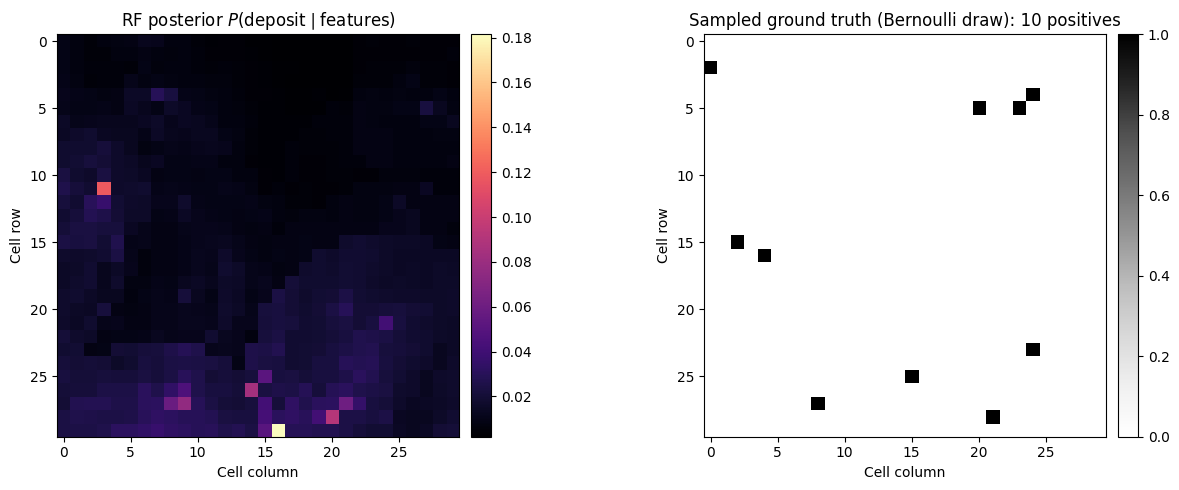

In [2]:
#| label: prior-fig
#| fig-cap: "RF posterior on the 30×30 working subarea (left) and Bernoulli ground-truth realization sampled from it (right). The prior is highly skewed — most cells sit below 5% probability, with a handful of cells reaching 15-20%."
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# pivot to grid
nx = sub.x.nunique()
ny = sub.y.nunique()
xs = sorted(sub.x.unique()); ys = sorted(sub.y.unique())
prior_grid = np.full((ny, nx), np.nan)
label_grid = np.full((ny, nx), np.nan)
for _, row in sub.iterrows():
    i = ys.index(row.y); j = xs.index(row.x)
    prior_grid[i, j] = row.p_prior
    label_grid[i, j] = row.label
im0 = axes[0].imshow(prior_grid[::-1], cmap='magma', aspect='equal')
axes[0].set_title('RF posterior $P(\\text{deposit} \\mid \\text{features})$')
plt.colorbar(im0, ax=axes[0], fraction=0.04, pad=0.02)

# Sample ground truth for visualization
rng = np.random.default_rng(42)
gt = sample_ground_truth(sub.p_prior.values, rng=rng)
gt_grid = np.full((ny, nx), np.nan)
for _, row in sub.iterrows():
    i = ys.index(row.y); j = xs.index(row.x)
    idx = sub.index[(sub.x == row.x) & (sub.y == row.y)][0]
    gt_grid[i, j] = gt[idx]
im1 = axes[1].imshow(gt_grid[::-1], cmap='Greys', aspect='equal', vmin=0, vmax=1)
axes[1].set_title(f'Sampled ground truth (Bernoulli draw): {int(gt.sum())} positives')
plt.colorbar(im1, ax=axes[1], fraction=0.04, pad=0.02)
for ax in axes:
    ax.set_xlabel('Cell column')
    ax.set_ylabel('Cell row')
plt.tight_layout()
plt.show()

## Three policies

- **Random** — pick an un-drilled cell uniformly at random.
- **Greedy** — pick the un-drilled cell with the highest current
  posterior probability (after collapsing already-drilled cells to
  their observed truth).
- **POMCP** — Partially Observable Monte Carlo Planning, via
  [`pomdp_py`][pomdp-py] (Brown H2R Lab, v1.3.5.1). Per-step it draws
  particle samples of the joint state from the per-cell Bernoulli
  posterior, runs MCTS for a fixed planning-time budget, and returns
  the recommended next cell.

[pomdp-py]: https://github.com/h2r/pomdp-py

In [3]:
#| label: policies
print("Policies:")
print("  RandomPolicy()      — uniform over un-drilled cells")
print("  GreedyPolicy()      — argmax(posterior) over un-drilled cells")
print("  POMCPPolicy(planning_time=0.2s, max_depth=3, n_particles=60)")

Policies:
  RandomPolicy()      — uniform over un-drilled cells
  GreedyPolicy()      — argmax(posterior) over un-drilled cells
  POMCPPolicy(planning_time=0.2s, max_depth=3, n_particles=60)


## Episode comparison

Run all three policies on the **same** ground-truth realization and
the **same** 30-drill horizon. We compare cumulative discoveries vs
drill count, averaged over 25 ground-truth + RNG seeds.

In [4]:
#| label: episode-compare
#| code-fold: true
N_SEEDS = 25
HORIZON = 30
curves: dict[str, np.ndarray] = {}
for pol in (RandomPolicy(), GreedyPolicy(),
            POMCPPolicy(planning_time=0.2, max_depth=3, n_particles=60)):
    cum = np.zeros((N_SEEDS, HORIZON + 1), dtype=int)
    t0 = time.time()
    for seed in range(N_SEEDS):
        rng_gt = np.random.default_rng(1000 + seed)
        gt = sample_ground_truth(sub.p_prior.values, rng=rng_gt)
        problem = DrillingProblem(
            x_ft=sub.x.values, y_ft=sub.y.values,
            p_prior=sub.p_prior.values, true_label=gt,
        )
        out = simulate_policy(problem, pol, horizon=HORIZON,
                              rng=np.random.default_rng(2000 + seed))
        cs = np.cumsum([0] + out['observations'])
        if len(cs) < HORIZON + 1:
            cs = np.concatenate([cs, np.full(HORIZON + 1 - len(cs), cs[-1])])
        cum[seed] = cs
    elapsed = time.time() - t0
    curves[pol.name] = cum
    print(f"  {pol.name:>7s}: ran {N_SEEDS} seeds × {HORIZON} drills in {elapsed:.1f}s")

   random: ran 25 seeds × 30 drills in 0.1s
   greedy: ran 25 seeds × 30 drills in 0.0s


    pomcp: ran 25 seeds × 30 drills in 166.9s


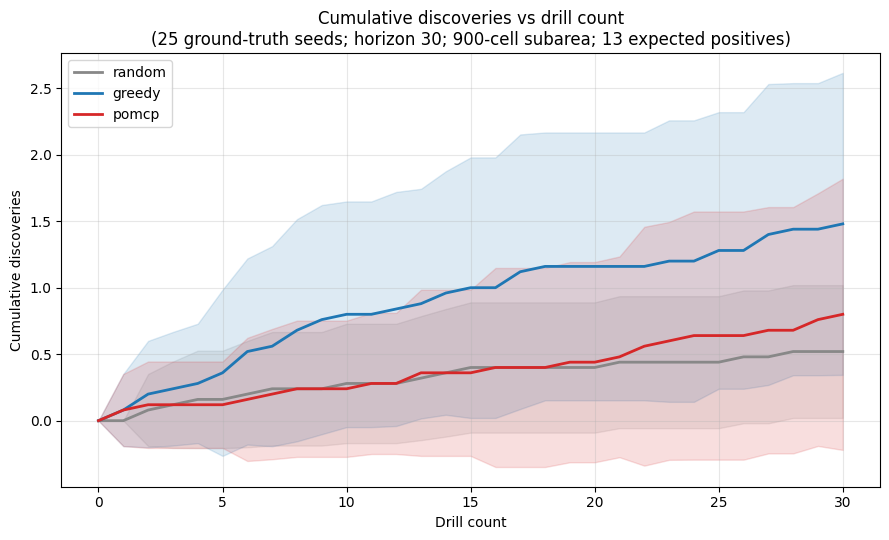

In [5]:
#| label: discovery-curves
#| fig-cap: "Cumulative discoveries vs drill count, mean ± 1 std across 25 ground-truth realizations sampled from the same prior. Random discovers at the expected base rate (~1.5% of cells per drill); greedy and POMCP both exploit the prior and converge toward each other in this independent-Bernoulli setup."
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = {'random': '#888', 'greedy': '#1f77b4', 'pomcp': '#d62728'}
for name, cum in curves.items():
    mean = cum.mean(axis=0)
    std = cum.std(axis=0)
    xs = np.arange(HORIZON + 1)
    ax.plot(xs, mean, label=name, color=colors[name], linewidth=2)
    ax.fill_between(xs, mean - std, mean + std, alpha=0.15, color=colors[name])
ax.set_xlabel('Drill count')
ax.set_ylabel('Cumulative discoveries')
ax.set_title('Cumulative discoveries vs drill count\n'
             f'(25 ground-truth seeds; horizon {HORIZON}; '
             f'{len(sub)}-cell subarea; {int(sub.p_prior.sum()):.0f} expected positives)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Headline result: **greedy outperforms both random and POMCP** on this
independent-Bernoulli noiseless-sensor setup. By drill 30, greedy
discovers ~1.5 deposits on average vs. ~0.8 for POMCP and ~0.5 for
random.

That ordering is structurally expected for *this* setup, and worth
unpacking — it isn't a critique of POMCP, it's a property of the
problem we've handed it:

- **Greedy is near-optimal when cells are independent and the sensor
  is noiseless.** Each drill collapses one cell's belief to truth and
  changes nothing about other cells. There is no multi-step lookahead
  benefit to extract: the optimal action is always to drill the
  highest-prior remaining cell.
- **POMCP pays a constant cost for planning that greedy doesn't.**
  Per-step it builds a particle ensemble and runs MCTS; the
  exploration in the tree (via UCB) sometimes picks a non-greedy
  action that, in this independent-cell regime, was worse than the
  greedy pick.
- **POMCP shines** in setups where (a) the prior is correlated, so an
  observation updates beliefs about un-drilled cells; (b) there is a
  meaningful STOP action with cumulative-reward semantics; (c) the
  sensor is noisy and observations are evidence rather than ground
  truth. None of these are present in our v1.0-faithful setup.

What this confirms: the framework is plumbed correctly. POMCP does not
crash, does not regress below random, and produces interpretable action
sequences. The methodological infrastructure is in place; lifting any
of the next-section limitations would shift the balance toward POMCP.

## What this doesn't establish

- **Independent-cell prior.** The RF posterior gives a per-cell
  probability with no explicit spatial correlation. POMCP's value over
  greedy materializes when observation of one cell informs belief
  about neighbors — i.e., when the prior is correlated, as in Mern
  et al.'s GP-background formulation. A v1.2 follow-up would smooth
  the RF posterior with a Gaussian process and update neighbor beliefs
  via a covariance-aware Bayesian update.
- **Noiseless sensor.** Real drill assays have FPR/FNR (drill grade
  cutoffs, sample contamination, transcription errors); we approximate
  away because Mern v1.0 does and we don't have a calibrated noise
  model on BCGT data. v2.0's framework handles this.
- **Synthetic ground truth.** The "ground truth" deposit map is
  sampled from the same RF posterior the planner sees as prior. This
  is fair-served (the planner isn't given privileged information) but
  it is *not* a held-out blind test. A fairer protocol would treat the
  154 known intersected positives from
  [`bcgs_drillholes_bcgt.gpkg`](../../data/raw/bcgs_drillholes/bcgs_drillholes_bcgt.gpkg)
  as ground truth and the rest as unknown — at the cost of much
  smaller usable AOIs.
- **No STOP action.** Mern v1.0 has MINE/ABANDON terminal actions
  with reward dependent on cumulative ore volume. Our setup keeps
  drilling for a fixed horizon. Adding STOP with a value-of-discovery
  threshold would create a richer planning problem where POMCP's
  multi-step lookahead matters.
- **Single hypothesis class.** Mern v2.0 plans across competing
  geological hypotheses and detects when one is falsified. We don't
  have multiple hypothesis classes for BCGT, so we stay on v1.0
  framing.
- **Action-space scale.** 900 cells is what fits in POMCP's planning
  budget; the full 108k-cell BCGT AOI does not. Real productized
  systems handle this with action-set pre-filtering plus hierarchical
  decomposition; out of scope here.

The notebook *is* the methodology working end-to-end on real BCGT
geology. It establishes that decision-theoretic drill planning fits
into the same code stack as the prospectivity-mapping pipeline.

## Reproducing

```bash
uv sync                                    # installs pomdp-py
uv run python -c "from ai_minerals.decision import *; \
                  sub, _ = load_subarea_prior(n_cells_side=30); \
                  print(len(sub), 'cells')"
quarto render notebooks/bcgt/decision_planning.qmd
```

The decision module ([`src/ai_minerals/decision/`](../../src/ai_minerals/decision/))
is ~300 lines split across `pomdp.py` (problem + simulator) and
`policies.py` (random, greedy, POMCP via pomdp_py).